---
## 0 · Imports & Shared Utilities

In [6]:
import time
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize


import os
import json

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

metrics = {}

Using device: cuda:0


---
## 1 · Shared Dataset

In [8]:
class CarDataset(Dataset):
    def __init__(self, root_dir, transform=None, tensor_transform=None,
                 class_transforms=None, base_samples=None):
        self.root_dir = root_dir
        self.transform = transform
        self.tensor_transform = tensor_transform
        self.class_transforms = class_transforms if class_transforms is not None else {}

        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {name: i for i, name in enumerate(self.class_names)}
        self.idx_to_class = {i: name for i, name in enumerate(self.class_names)}

        if base_samples is not None:
            self.base_samples = base_samples
        else:
            self.base_samples = []
            for class_name in self.class_names:
                class_dir = os.path.join(root_dir, class_name)
                for image_file in os.listdir(class_dir):
                    self.base_samples.append(
                        (os.path.join(class_dir, image_file),
                         self.class_to_idx[class_name])
                    )

        self.samples = []
        for img_path, label_idx in self.base_samples:
            self.samples.append((img_path, label_idx, None))
            class_name = self.idx_to_class[label_idx]
            if class_name in self.class_transforms:
                aug_list = self.class_transforms[class_name]
                if callable(aug_list):
                    aug_list = [aug_list]
                for aug_transform in aug_list:
                    self.samples.append((img_path, label_idx, aug_transform))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_idx, aug_transform = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        if aug_transform is not None:
            image = aug_transform(image)
        if self.tensor_transform:
            image = self.tensor_transform(image)
        return image, label_idx

In [9]:
crop_only   = transforms.RandomResizedCrop(224, scale=(0.8, 1.0))
rotate_only = transforms.RandomRotation(30)

class_transforms = {
    'Van':       [crop_only, rotate_only],
    'Wagon':     [crop_only, rotate_only],
    'Minivan':   [crop_only, rotate_only],
    'Hatchback': [crop_only, rotate_only],
}

base_aug = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.Lambda(lambda img: img.convert('RGB')),
])

clean_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert('RGB')),
])

torch.manual_seed(42)

_probe = CarDataset(root_dir='/root/.cache/kagglehub/datasets/mayurmahurkar/stanford-car-body-type-data/versions/1/stanford_cars_type/', transform=base_aug,
                    tensor_transform=transforms.ToTensor())

train_size     = int(0.8 * len(_probe))
indices        = torch.randperm(len(_probe)).tolist()
TRAIN_INDICES  = indices[:train_size]
TEST_INDICES   = indices[train_size:]
TRAIN_BASE     = [_probe.base_samples[i] for i in TRAIN_INDICES]
TEST_BASE      = [_probe.base_samples[i] for i in TEST_INDICES]
NUM_CLASSES    = len(_probe.class_names)

print(f'Classes ({NUM_CLASSES}): {_probe.class_names}')
print(f'Train base: {len(TRAIN_BASE)} | Test base: {len(TEST_BASE)}')

def mixup_batch(inputs, labels, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(inputs.size(0), device=inputs.device)
    return lam * inputs + (1.0 - lam) * inputs[idx], labels, labels[idx], lam

Classes (10): ['Cab', 'Convertible', 'Coupe', 'Hatchback', 'Minivan', 'Other', 'SUV', 'Sedan', 'Van', 'Wagon']
Train base: 6515 | Test base: 1629


---
## 2 · Scratch CNN (CarNet)

In [10]:
cnn_tensor_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

cnn_train_ds = CarDataset(
    root_dir='stanford_cars_type/',
    transform=base_aug,
    tensor_transform=cnn_tensor_tf,
    class_transforms=class_transforms,
    base_samples=TRAIN_BASE,
)

cnn_test_ds = CarDataset(
    root_dir='stanford_cars_type/',
    transform=clean_transform,
    tensor_transform=cnn_tensor_tf,
    class_transforms=None,
    base_samples=TEST_BASE,
)

cnn_train_dl = torch.utils.data.DataLoader(cnn_train_ds, batch_size=32, shuffle=True,  num_workers=2)
cnn_test_dl  = torch.utils.data.DataLoader(cnn_test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f'CNN train samples (with aug): {len(cnn_train_ds)}')

CNN train samples (with aug): 8663


In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if stride == 1:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CarNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.layer1 = nn.Sequential(ConvBlock(3, 32),   ConvBlock(32, 32))
        self.layer2 = nn.Sequential(ConvBlock(32, 64, stride=2),  ConvBlock(64, 64))
        self.layer3 = nn.Sequential(ConvBlock(64, 128, stride=2), ConvBlock(128, 128))
        self.layer4 = nn.Sequential(ConvBlock(128, 256, stride=2),ConvBlock(256, 256))
        self.pool   = nn.AdaptiveAvgPool2d((1, 1))
        self.fc     = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.pool(x);   x = torch.flatten(x, 1)
        return self.fc(x)

In [12]:
def train_epoch(model, loader, optimizer, criterion, use_mixup=False):
    model.train()
    running_loss, n = 0.0, 0
    correct_train, total_train = 0, 0
    for i, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        if use_mixup and np.random.rand() < 0.5:
            mixed, la, lb, lam = mixup_batch(inputs, labels)
            out  = model(mixed)
            loss = lam * criterion(out, la) + (1 - lam) * criterion(out, lb)
            _, pred = torch.max(out, 1)
            correct_train += (lam * (pred == la).float() + (1-lam) * (pred == lb).float()).sum().item()
        else:
            out  = model(inputs)
            loss = criterion(out, labels)
            _, pred = torch.max(out, 1)
            correct_train += (pred == labels).sum().item()
        loss.backward(); optimizer.step()
        running_loss += loss.item(); n += 1
        total_train  += labels.size(0)
        if i % 100 == 99:
            print(f'  batch {i+1:4d} | loss {running_loss/100:.3f}')
            running_loss = 0.0
    return 100 * correct_train / total_train


def eval_epoch(model, loader, criterion):
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            out = model(inputs)
            val_loss += criterion(out, labels).item()
            _, pred = torch.max(out, 1)
            correct += (pred == labels).sum().item()
            total   += labels.size(0)
    return val_loss / len(loader), 100 * correct / total

In [13]:
cnn_net = CarNet(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

cnn_train_accs, cnn_val_accs = [], []
cnn_start = time.time()

print('=== CNN Phase 1: Initial Training (5 epochs) ===')
P1_EPOCHS = 5
opt = optim.Adam(cnn_net.parameters(), lr=1e-3, weight_decay=1e-4)
sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=P1_EPOCHS, eta_min=1e-5)

for ep in range(P1_EPOCHS):
    tr_acc = train_epoch(cnn_net, cnn_train_dl, opt, criterion, use_mixup=False)
    vl, va = eval_epoch(cnn_net, cnn_test_dl, criterion)
    cnn_train_accs.append(tr_acc); cnn_val_accs.append(va)
    print(f'[P1] Epoch {ep+1}/{P1_EPOCHS} | Train Acc: {tr_acc:.2f}% | Val Loss: {vl:.3f} | Val Acc: {va:.2f}%')
    sch.step()

print('\n=== CNN Phase 2: Fine-tuning with MixUp (20 epochs) ===')
P2_EPOCHS = 20
opt = optim.Adam(cnn_net.parameters(), lr=3e-4, weight_decay=1e-4)
sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=P2_EPOCHS, eta_min=1e-6)

for ep in range(P2_EPOCHS):
    tr_acc = train_epoch(cnn_net, cnn_train_dl, opt, criterion, use_mixup=True)
    vl, va = eval_epoch(cnn_net, cnn_test_dl, criterion)
    cnn_train_accs.append(tr_acc); cnn_val_accs.append(va)
    print(f'[P2] Epoch {ep+1}/{P2_EPOCHS} | Train Acc: {tr_acc:.2f}% | Val Loss: {vl:.3f} | Val Acc: {va:.2f}%')
    sch.step()

cnn_total_time = time.time() - cnn_start

_, cnn_final_acc = eval_epoch(cnn_net, cnn_test_dl, criterion)
cnn_trainable = sum(p.numel() for p in cnn_net.parameters() if p.requires_grad)

print(f'\nCNN Final Test Accuracy : {cnn_final_acc:.2f}%')
print(f'CNN Trainable Parameters: {cnn_trainable:,}')
print(f'CNN Total Training Time : {cnn_total_time/60:.1f} min')

=== CNN Phase 1: Initial Training (5 epochs) ===
  batch  100 | loss 2.297
  batch  200 | loss 2.215
[P1] Epoch 1/5 | Train Acc: 20.51% | Val Loss: 2.153 | Val Acc: 23.94%
  batch  100 | loss 2.110
  batch  200 | loss 2.081
[P1] Epoch 2/5 | Train Acc: 26.32% | Val Loss: 2.106 | Val Acc: 23.27%
  batch  100 | loss 1.998
  batch  200 | loss 1.960
[P1] Epoch 3/5 | Train Acc: 31.14% | Val Loss: 1.926 | Val Acc: 33.27%
  batch  100 | loss 1.872
  batch  200 | loss 1.877
[P1] Epoch 4/5 | Train Acc: 36.20% | Val Loss: 1.901 | Val Acc: 35.11%
  batch  100 | loss 1.788
  batch  200 | loss 1.770
[P1] Epoch 5/5 | Train Acc: 40.62% | Val Loss: 1.797 | Val Acc: 40.39%

=== CNN Phase 2: Fine-tuning with MixUp (20 epochs) ===
  batch  100 | loss 1.843
  batch  200 | loss 1.801
[P2] Epoch 1/20 | Train Acc: 39.48% | Val Loss: 1.876 | Val Acc: 35.11%
  batch  100 | loss 1.828
  batch  200 | loss 1.802
[P2] Epoch 2/20 | Train Acc: 40.65% | Val Loss: 1.828 | Val Acc: 38.61%
  batch  100 | loss 1.785
  bat

---
## 3 · ResNet-50 Transfer Learning

In [14]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

rn_tensor_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

rn_train_ds = CarDataset(
    root_dir='stanford_cars_type/',
    transform=base_aug,
    tensor_transform=rn_tensor_tf,
    class_transforms=class_transforms,
    base_samples=TRAIN_BASE,
)

rn_test_ds = CarDataset(
    root_dir='stanford_cars_type/',
    transform=clean_transform,
    tensor_transform=rn_tensor_tf,
    class_transforms=None,
    base_samples=TEST_BASE,
)

rn_train_dl = torch.utils.data.DataLoader(rn_train_ds, batch_size=32, shuffle=True,  num_workers=2)
rn_test_dl  = torch.utils.data.DataLoader(rn_test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f'ResNet train samples (with aug): {len(rn_train_ds)}')

ResNet train samples (with aug): 8663


In [15]:
class TransferModel(nn.Module):
    def __init__(self, num_classes, base_model):
        super().__init__()
        self.base_model = base_model
        self.head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.head(self.base_model(x))


backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()
tfmodel = TransferModel(NUM_CLASSES, backbone).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 86.3MB/s]


In [16]:
rn_train_accs, rn_val_accs = [], []
rn_start = time.time()

print('=== ResNet Phase 1: Head only (3 epochs) ===')
for p in tfmodel.base_model.parameters():
    p.requires_grad = False

P1_EPOCHS = 3
opt = optim.Adam(filter(lambda p: p.requires_grad, tfmodel.parameters()), lr=1e-3, weight_decay=1e-4)
sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=P1_EPOCHS, eta_min=1e-5)

for ep in range(P1_EPOCHS):
    tr_acc = train_epoch(tfmodel, rn_train_dl, opt, criterion, use_mixup=False)
    vl, va = eval_epoch(tfmodel, rn_test_dl, criterion)
    rn_train_accs.append(tr_acc); rn_val_accs.append(va)
    print(f'[P1] Epoch {ep+1}/{P1_EPOCHS} | Train Acc: {tr_acc:.2f}% | Val Loss: {vl:.3f} | Val Acc: {va:.2f}%')
    sch.step()

print('\n=== ResNet Phase 2: Fine-tuning layer3+layer4 with MixUp (20 epochs) ===')
for name, p in tfmodel.base_model.named_parameters():
    if 'layer3' in name or 'layer4' in name:
        p.requires_grad = True

P2_EPOCHS = 20
opt = optim.Adam(filter(lambda p: p.requires_grad, tfmodel.parameters()), lr=3e-4, weight_decay=1e-4)
sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=P2_EPOCHS, eta_min=1e-6)

for ep in range(P2_EPOCHS):
    tr_acc = train_epoch(tfmodel, rn_train_dl, opt, criterion, use_mixup=True)
    vl, va = eval_epoch(tfmodel, rn_test_dl, criterion)
    rn_train_accs.append(tr_acc); rn_val_accs.append(va)
    print(f'[P2] Epoch {ep+1}/{P2_EPOCHS} | Train Acc: {tr_acc:.2f}% | Val Loss: {vl:.3f} | Val Acc: {va:.2f}%')
    sch.step()

rn_total_time = time.time() - rn_start

_, rn_final_acc = eval_epoch(tfmodel, rn_test_dl, criterion)
rn_trainable_p2 = sum(p.numel() for p in tfmodel.parameters() if p.requires_grad)
rn_trainable_p1 = sum(p.numel() for p in tfmodel.head.parameters())

print(f'\nResNet Final Test Accuracy      : {rn_final_acc:.2f}%')
print(f'ResNet Trainable Params (Phase 1): {rn_trainable_p1:,}')
print(f'ResNet Trainable Params (Phase 2): {rn_trainable_p2:,}')
print(f'ResNet Total Training Time       : {rn_total_time/60:.1f} min')

=== ResNet Phase 1: Head only (3 epochs) ===
  batch  100 | loss 1.704
  batch  200 | loss 1.481
[P1] Epoch 1/3 | Train Acc: 52.90% | Val Loss: 1.456 | Val Acc: 55.99%
  batch  100 | loss 1.328
  batch  200 | loss 1.361
[P1] Epoch 2/3 | Train Acc: 62.89% | Val Loss: 1.401 | Val Acc: 60.41%
  batch  100 | loss 1.246
  batch  200 | loss 1.242
[P1] Epoch 3/3 | Train Acc: 67.92% | Val Loss: 1.328 | Val Acc: 63.97%

=== ResNet Phase 2: Fine-tuning layer3+layer4 with MixUp (20 epochs) ===
  batch  100 | loss 1.624
  batch  200 | loss 1.297
[P2] Epoch 1/20 | Train Acc: 63.26% | Val Loss: 1.113 | Val Acc: 73.66%
  batch  100 | loss 1.091
  batch  200 | loss 1.092
[P2] Epoch 2/20 | Train Acc: 77.65% | Val Loss: 1.091 | Val Acc: 73.30%
  batch  100 | loss 0.995
  batch  200 | loss 0.967
[P2] Epoch 3/20 | Train Acc: 82.13% | Val Loss: 0.947 | Val Acc: 80.66%
  batch  100 | loss 0.990
  batch  200 | loss 0.956
[P2] Epoch 4/20 | Train Acc: 83.78% | Val Loss: 1.005 | Val Acc: 78.70%
  batch  100 | l

---
## 3b · Save the TransferModel

Run this cell once after training. You get 3 files — keep them together whenever you want to use the model.

In [17]:
torch.save(tfmodel.state_dict(), 'tfmodel.pth')
print('Saved weights        → tfmodel.pth')

with open('class_to_idx.json', 'w') as f:
    json.dump(_probe.class_to_idx, f, indent=2)
print('Saved class mapping  → class_to_idx.json')

with open('model_config.json', 'w') as f:
    json.dump({'num_classes': NUM_CLASSES}, f, indent=2)
print('Saved model config   → model_config.json')

print('\nKeep these 3 files together: tfmodel.pth, class_to_idx.json, model_config.json')

Saved weights        → tfmodel.pth
Saved class mapping  → class_to_idx.json
Saved model config   → model_config.json

Keep these 3 files together: tfmodel.pth, class_to_idx.json, model_config.json


---
## 4 · Model Comparison Table

In [ ]:
def fmt_time(seconds):
    m, s = divmod(int(seconds), 60)
    return f'{m}m {s}s'

cnn_best_train = max(cnn_train_accs)
cnn_best_val   = max(cnn_val_accs)

rn_best_train  = max(rn_train_accs)
rn_best_val    = max(rn_val_accs)

cnn_total_params = sum(p.numel() for p in cnn_net.parameters())
rn_total_params  = sum(p.numel() for p in tfmodel.parameters())

comparison = {
    'Metric': [
        'Architecture',
        'Best Training Accuracy',
        'Best Validation Accuracy',
        'Final Test Accuracy',
        'Total Parameters',
        'Trainable Params — Phase 1',
        'Trainable Params — Phase 2',
        'Training Time (approx.)',
        'Phase 1 Strategy',
        'Phase 2 Strategy',
        'Normalisation',
        'Pretrained Weights',
    ],

    'Scratch CNN (CarNet)': [
        'Custom 4-layer ConvNet',
        f'{cnn_best_train:.2f}%',
        f'{cnn_best_val:.2f}%',
        f'{cnn_final_acc:.2f}%',
        f'{cnn_total_params:,}',
        f'{cnn_trainable:,} (all)',
        f'{cnn_trainable:,} (all)',
        fmt_time(cnn_total_time),
        'Full training, no mixup',
        'Full training + MixUp (α=0.2)',
        'Mean=0.5, Std=0.5',
        'None (random init)',
    ],

    'ResNet-50 Transfer Learning': [
        'ResNet-50 backbone + custom head',
        f'{rn_best_train:.2f}%',
        f'{rn_best_val:.2f}%',
        f'{rn_final_acc:.2f}%',
        f'{rn_total_params:,}',
        f'{rn_trainable_p1:,} (head only)',
        f'{rn_trainable_p2:,} (head + layer3/4)',
        fmt_time(rn_total_time),
        'Frozen backbone, train head only',
        'Unfreeze layer3+layer4 + MixUp (α=0.2)',
        'ImageNet mean/std',
        'ImageNet (IMAGENET1K_V1)',
    ],
}

df = pd.DataFrame(comparison).set_index('Metric')

try:
    from IPython.display import display

    styled_df = (
        df.style
        .set_table_styles([
            {
                'selector': 'th',
                'props': [
                    ('background-color', '#2c3e50'),
                    ('color', 'white'),
                    ('font-size', '13px'),
                    ('text-align', 'center'),
                    ('padding', '8px')
                ]
            },
            {
                'selector': 'td',
                'props': [
                    ('text-align', 'center'),
                    ('font-size', '12px'),
                    ('color', 'white'),
                    ('padding', '6px')
                ]
            },
            {
                'selector': 'tr:nth-child(even) td',
                'props': [
                    ('background-color', '#f2f2f2'),
                    ('color', 'black')
                ]
            },
            {
                'selector': 'tr:nth-child(odd) td',
                'props': [
                    ('background-color', '#3b3b3b'),
                    ('color', 'white')
                ]
            },
            {
                'selector': 'caption',
                'props': [
                    ('caption-side', 'top'),
                    ('font-size', '16px'),
                    ('font-weight', 'bold'),
                    ('padding', '10px')
                ]
            }

        ])
        .set_caption('Model Comparison: Scratch CNN vs Transfer Learning')
    )

    display(styled_df)

except Exception:
    print(df.to_string())

,Scratch CNN (CarNet),ResNet-50 Transfer Learning
Metric,,
Architecture,Custom 4-layer ConvNet,ResNet-50 backbone + custom head
Best Training Accuracy,65.38%,95.67%
Best Validation Accuracy,53.53%,91.84%
Final Test Accuracy,53.53%,91.84%
Total Parameters,"1,208,618","24,563,274"
Trainable Params — Phase 1,"1,208,618 (all)","1,055,242 (head only)"
Trainable Params — Phase 2,"1,208,618 (all)","23,118,346 (head + layer3/4)"
Training Time (approx.),38m 15s,41m 15s
Phase 1 Strategy,"Full training, no mixup","Frozen backbone, train head only"


## Learning Curve Plot

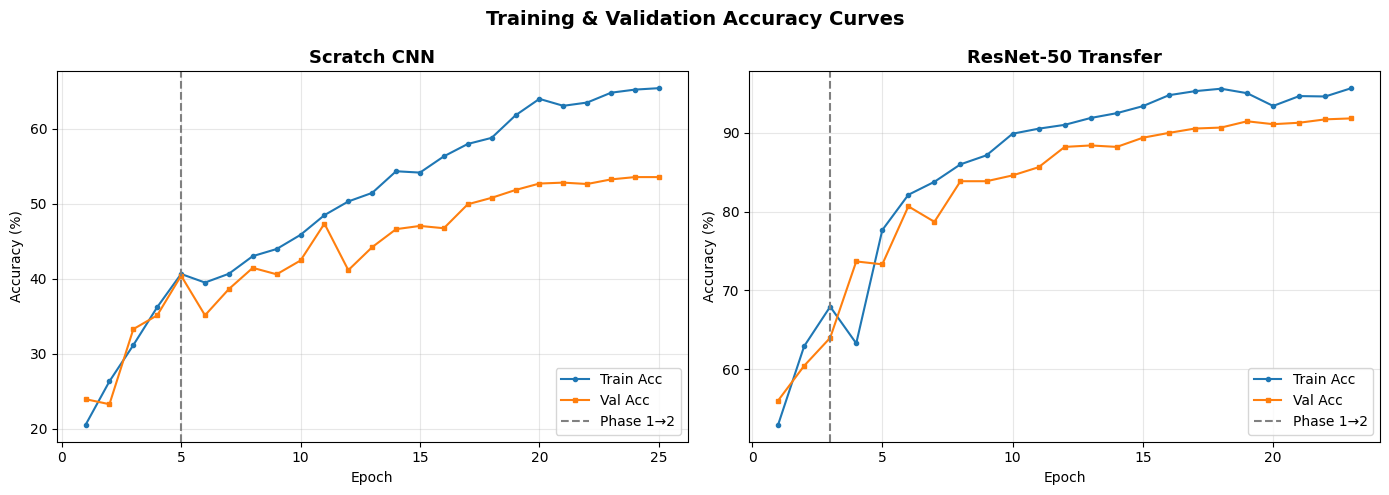

Learning curves saved to learning_curves.png


In [19]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, accs, title in [
    (axes[0], (cnn_train_accs, cnn_val_accs),  'Scratch CNN'),
    (axes[1], (rn_train_accs,  rn_val_accs),   'ResNet-50 Transfer'),
]:
    tr_a, va_a = accs
    ep = range(1, len(tr_a) + 1)
    ax.plot(ep, tr_a, label='Train Acc', marker='o', markersize=3)
    ax.plot(ep, va_a, label='Val Acc',   marker='s', markersize=3)
    ax.axvline(x=5 if title.startswith('Scratch') else 3,
                color='grey', linestyle='--', label='Phase 1→2')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Training & Validation Accuracy Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()
print('Learning curves saved to learning_curves.png')


---
## 5 · Evaluation — ResNet-50 Transfer Model


In [20]:
tfmodel.eval()
all_labels  = []
all_preds   = []
all_probs   = []

with torch.no_grad():
    for inputs, labels in rn_test_dl:
        inputs, labels = inputs.to(device), labels.to(device)
        logits = tfmodel(inputs)
        probs  = torch.softmax(logits, dim=1)
        _, preds = torch.max(logits, 1)
        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds  = np.concatenate(all_preds)
all_probs  = np.concatenate(all_probs)

class_names = _probe.class_names
NUM_CLASSES  = len(class_names)
print(f"Collected {len(all_labels)} test samples across {NUM_CLASSES} classes.")


Collected 1629 test samples across 10 classes.


In [21]:
acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("=" * 55)
print("  ResNet-50 Transfer Model — Evaluation Summary")
print("=" * 55)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%  (weighted)")
print(f"  Recall    : {recall*100:.2f}%  (weighted)")
print(f"  F1-Score  : {f1*100:.2f}%  (weighted)")
print("=" * 55)
print()
print("Per-class Classification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=class_names, zero_division=0))


  ResNet-50 Transfer Model — Evaluation Summary
  Accuracy  : 91.84%
  Precision : 91.97%  (weighted)
  Recall    : 91.84%  (weighted)
  F1-Score  : 91.77%  (weighted)

Per-class Classification Report:
              precision    recall  f1-score   support

         Cab       0.96      0.97      0.97       135
 Convertible       0.96      0.88      0.92       215
       Coupe       0.86      0.91      0.89       234
   Hatchback       0.91      0.84      0.88       116
     Minivan       1.00      0.84      0.91        57
       Other       0.88      0.77      0.82       104
         SUV       0.94      0.96      0.95       302
       Sedan       0.90      0.97      0.93       365
         Van       0.98      0.98      0.98        50
       Wagon       0.93      0.82      0.88        51

    accuracy                           0.92      1629
   macro avg       0.93      0.90      0.91      1629
weighted avg       0.92      0.92      0.92      1629



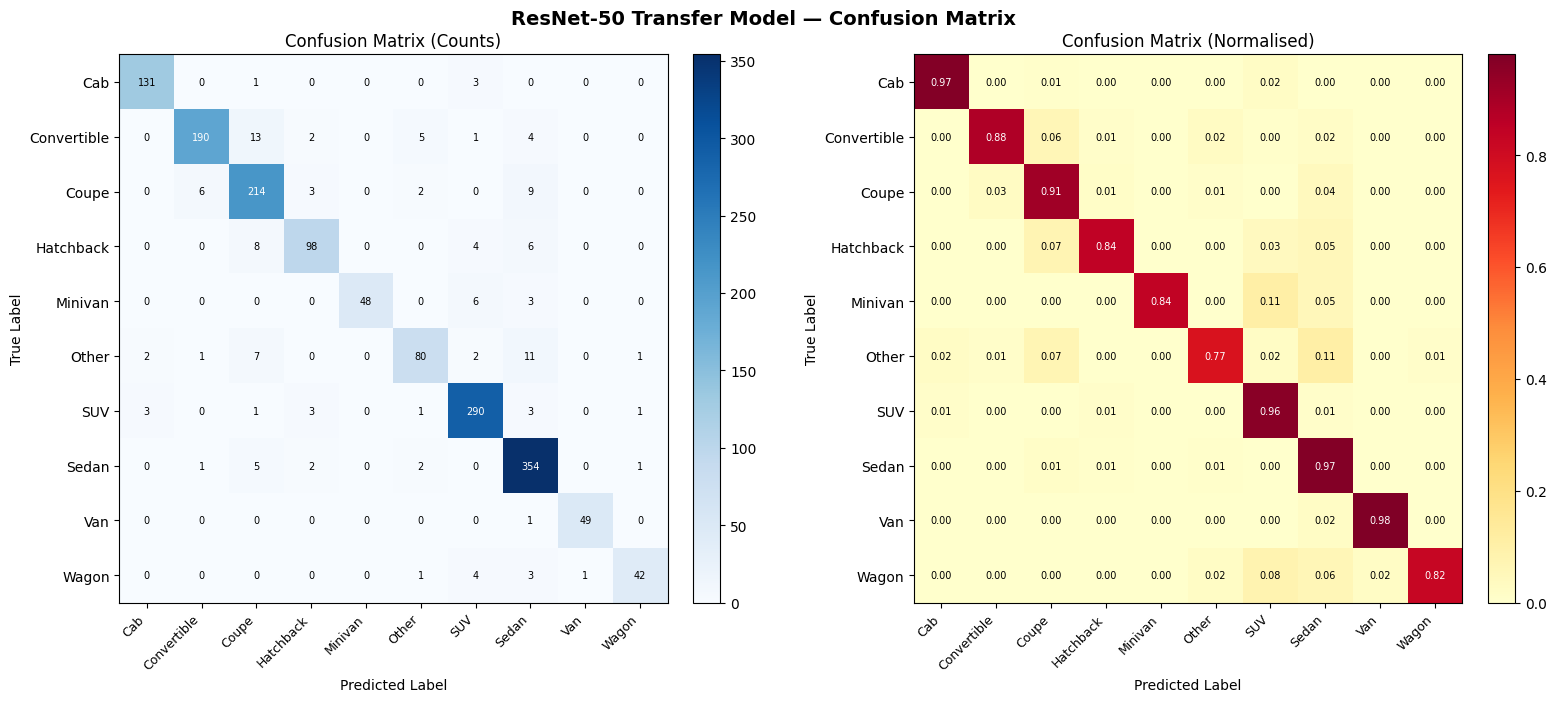

Saved → transfer_confusion_matrix.png


In [22]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, fmt in [
    (axes[0], cm,      'Confusion Matrix (Counts)',      'd'),
    (axes[1], cm_norm, 'Confusion Matrix (Normalised)',  '.2f'),
]:
    im = ax.imshow(data, interpolation='nearest',
                   cmap='Blues' if fmt == 'd' else 'YlOrRd')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=class_names,
        yticklabels=class_names,
        title=title,
        ylabel='True Label',
        xlabel='Predicted Label',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = f'{data[i,j]:{fmt}}'
            ax.text(j, i, val, ha='center', va='center', fontsize=7,
                    color='white' if data[i,j] > thresh else 'black')

plt.suptitle('ResNet-50 Transfer Model — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('transfer_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → transfer_confusion_matrix.png')


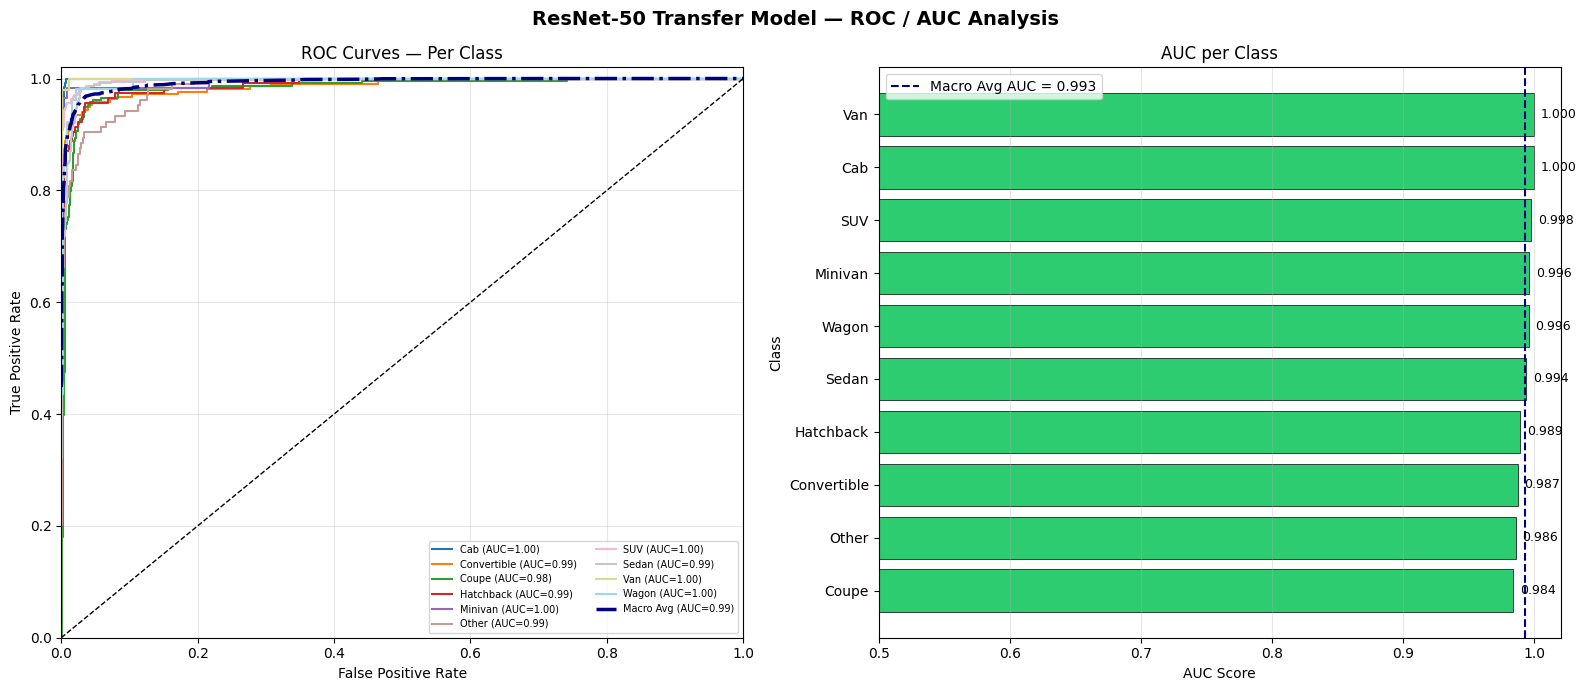

Macro-average AUC: 0.9930
Saved → transfer_roc_auc.png


In [23]:
y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= NUM_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
cmap = plt.get_cmap('tab20', NUM_CLASSES)
for i in range(NUM_CLASSES):
    ax.plot(fpr_dict[i], tpr_dict[i], color=cmap(i), lw=1.5,
            label=f'{class_names[i]} (AUC={roc_auc_dict[i]:.2f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.plot(all_fpr, mean_tpr, color='navy', lw=2.5, linestyle='-.',
        label=f'Macro Avg (AUC={macro_auc:.2f})')
ax.set(xlim=[0,1], ylim=[0,1.02],
       title='ROC Curves — Per Class',
       xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(fontsize=7, loc='lower right', ncol=2)
ax.grid(alpha=0.3)

ax2 = axes[1]
sorted_idx = np.argsort([roc_auc_dict[i] for i in range(NUM_CLASSES)])
bar_aucs   = [roc_auc_dict[i] for i in sorted_idx]
bar_names  = [class_names[i] for i in sorted_idx]
colors     = ['#e74c3c' if v < 0.85 else '#2ecc71' for v in bar_aucs]
bars = ax2.barh(bar_names, bar_aucs, color=colors, edgecolor='black', linewidth=0.5)
ax2.axvline(x=macro_auc, color='navy', linestyle='--', lw=1.5,
            label=f'Macro Avg AUC = {macro_auc:.3f}')
for bar, val in zip(bars, bar_aucs):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax2.set(xlim=[0.5, 1.02],
        title='AUC per Class',
        xlabel='AUC Score', ylabel='Class')
ax2.legend(); ax2.grid(alpha=0.3, axis='x')

plt.suptitle('ResNet-50 Transfer Model — ROC / AUC Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('transfer_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Macro-average AUC: {macro_auc:.4f}')
print('Saved → transfer_roc_auc.png')


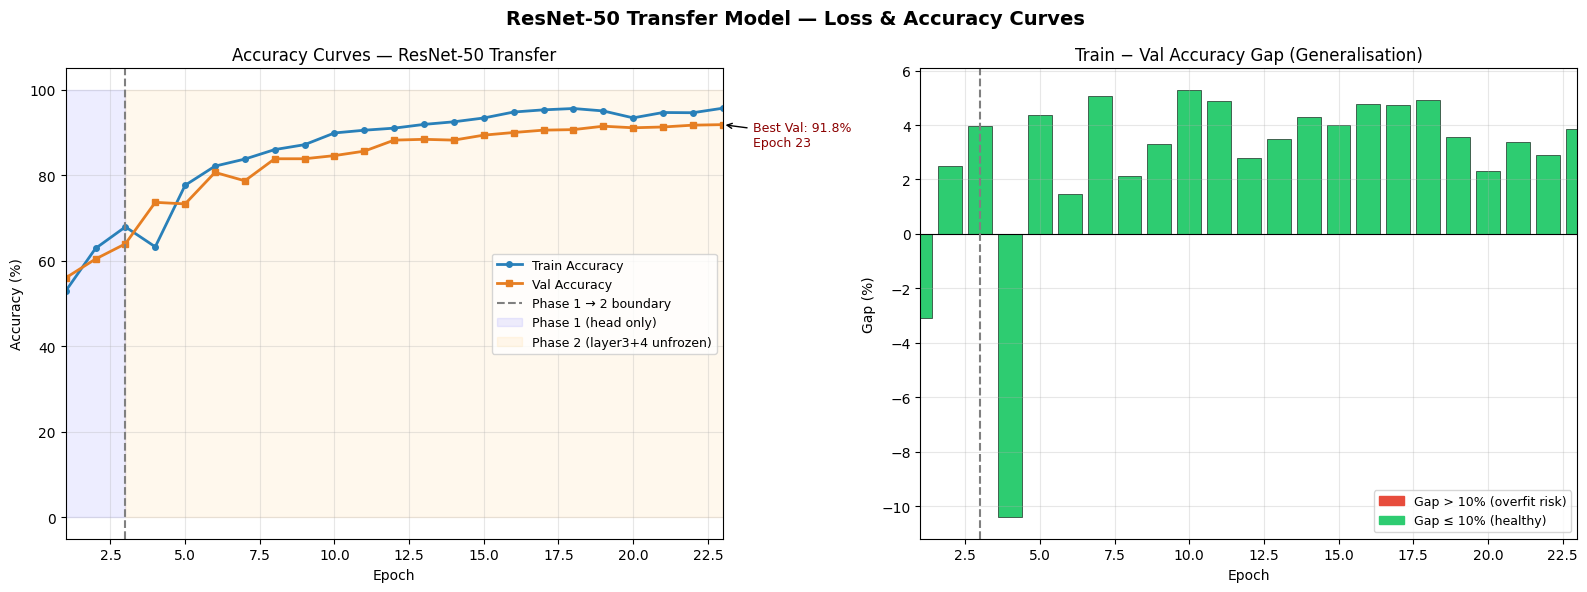

Saved → transfer_accuracy_curves.png


In [24]:
epochs_total = len(rn_train_accs)
ep_range     = range(1, epochs_total + 1)
phase_split  = 3

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(ep_range, rn_train_accs, label='Train Accuracy', marker='o',
        markersize=4, color='#2980b9', linewidth=2)
ax.plot(ep_range, rn_val_accs,   label='Val Accuracy',   marker='s',
        markersize=4, color='#e67e22', linewidth=2)
ax.axvline(x=phase_split, color='grey', linestyle='--', linewidth=1.5,
           label='Phase 1 → 2 boundary')
ax.fill_betweenx([0, 100], 0, phase_split, alpha=0.07, color='blue',
                 label='Phase 1 (head only)')
ax.fill_betweenx([0, 100], phase_split, epochs_total, alpha=0.07, color='orange',
                 label='Phase 2 (layer3+4 unfrozen)')
ax.set(title='Accuracy Curves — ResNet-50 Transfer',
       xlabel='Epoch', ylabel='Accuracy (%)',
       xlim=[1, epochs_total])
ax.legend(fontsize=9); ax.grid(alpha=0.3)

best_ep = int(np.argmax(rn_val_accs)) + 1
best_va = max(rn_val_accs)
ax.annotate(f'Best Val: {best_va:.1f}%\nEpoch {best_ep}',
            xy=(best_ep, best_va),
            xytext=(best_ep + 1, best_va - 5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='darkred')

ax2 = axes[1]
gap = np.array(rn_train_accs) - np.array(rn_val_accs)
ax2.bar(ep_range, gap,
        color=['#e74c3c' if g > 10 else '#2ecc71' for g in gap],
        edgecolor='black', linewidth=0.4)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.axvline(x=phase_split, color='grey', linestyle='--', linewidth=1.5,
            label='Phase 1 → 2 boundary')
red_patch   = mpatches.Patch(color='#e74c3c', label='Gap > 10% (overfit risk)')
green_patch = mpatches.Patch(color='#2ecc71', label='Gap ≤ 10% (healthy)')
ax2.legend(handles=[red_patch, green_patch], fontsize=9)
ax2.set(title='Train − Val Accuracy Gap (Generalisation)',
        xlabel='Epoch', ylabel='Gap (%)',
        xlim=[1, epochs_total])
ax2.grid(alpha=0.3)

plt.suptitle('ResNet-50 Transfer Model — Loss & Accuracy Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('transfer_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → transfer_accuracy_curves.png')


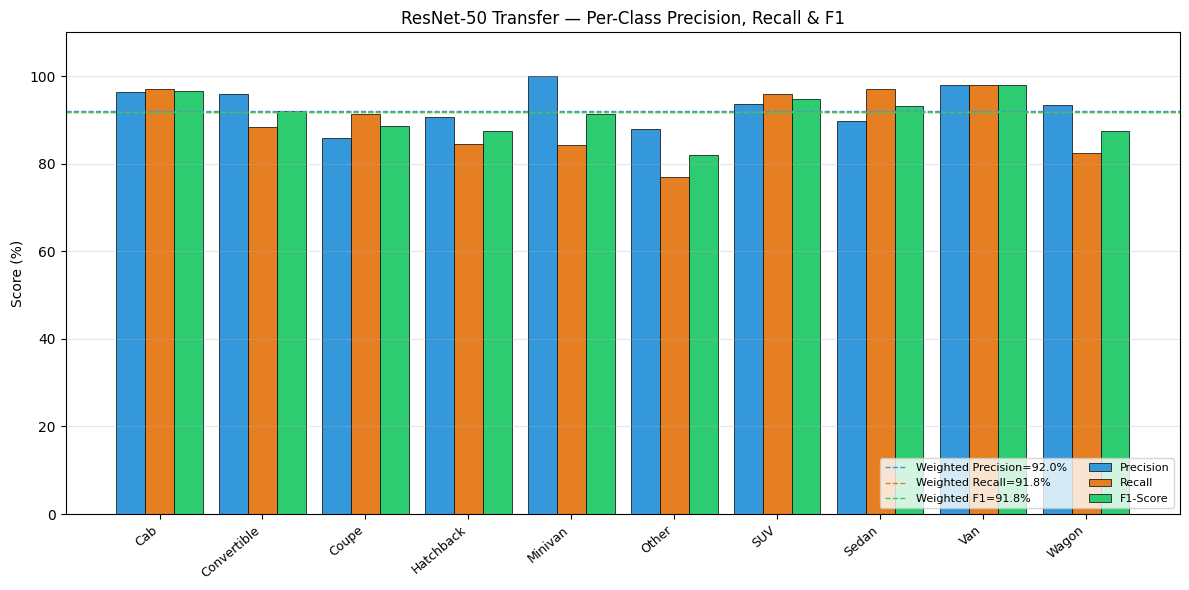

Saved → transfer_per_class_metrics.png


In [ ]:
p, r, f, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=list(range(NUM_CLASSES)),
    average=None, zero_division=0
)

x = np.arange(NUM_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(max(12, NUM_CLASSES * 1.2), 6))
ax.bar(x - width, p * 100, width, label='Precision', color='#3498db', edgecolor='black', linewidth=0.5)
ax.bar(x,         r * 100, width, label='Recall',    color='#e67e22', edgecolor='black', linewidth=0.5)
ax.bar(x + width, f * 100, width, label='F1-Score',  color='#2ecc71', edgecolor='black', linewidth=0.5)

ax.axhline(y=precision * 100, color='#3498db', linestyle='--', lw=1, label=f'Weighted Precision={precision*100:.1f}%')
ax.axhline(y=recall    * 100, color='#e67e22', linestyle='--', lw=1, label=f'Weighted Recall={recall*100:.1f}%')
ax.axhline(y=f1        * 100, color='#2ecc71', linestyle='--', lw=1, label=f'Weighted F1={f1*100:.1f}%')

ax.set(xticks=x, xticklabels=class_names,
       title='ResNet-50 Transfer — Per-Class Precision, Recall & F1',
       ylabel='Score (%)', ylim=[0, 110])
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.legend(fontsize=8, loc='lower right', ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('transfer_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → transfer_per_class_metrics.png')
